### Рекомендация товаров

### Импортирование библиотек

In [1]:
import numpy as np
import pandas as pd
import datetime
import time
import matplotlib.pyplot as plt
import seaborn as sns

### Загрузка датасета

In [2]:
events_df = pd.read_csv('events.csv')
events_df.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [3]:
events_df.shape

(2756101, 5)

In [4]:
all_customers = events_df.visitorid.unique()
all_customers.size

1407580

In [5]:
customer_purchased = events_df[events_df.transactionid.notnull()].visitorid.unique()
customer_purchased.size

11719

In [6]:
events_df['event'].unique()

<ArrowStringArray>
['view', 'addtocart', 'transaction']
Length: 3, dtype: str

In [8]:
events_df[events_df.visitorid==102019].sort_values('timestamp')

,timestamp,visitorid,event,itemid,transactionid
19690,1433175714335,102019,view,49521,NaN
19501,1433175801314,102019,addtocart,49521,NaN
14842,1433175812596,102019,view,150318,NaN
19573,1433175871497,102019,view,49521,NaN
8701,1433175894837,102019,view,49521,NaN
19708,1433175945872,102019,view,150318,NaN
8740,1433176042269,102019,view,49521,NaN
814,1433176736375,102019,transaction,150318,13556.0
19724,1433176736422,102019,transaction,49521,13556.0


In [9]:
events_count = events_df['event'].value_counts()
events_count

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

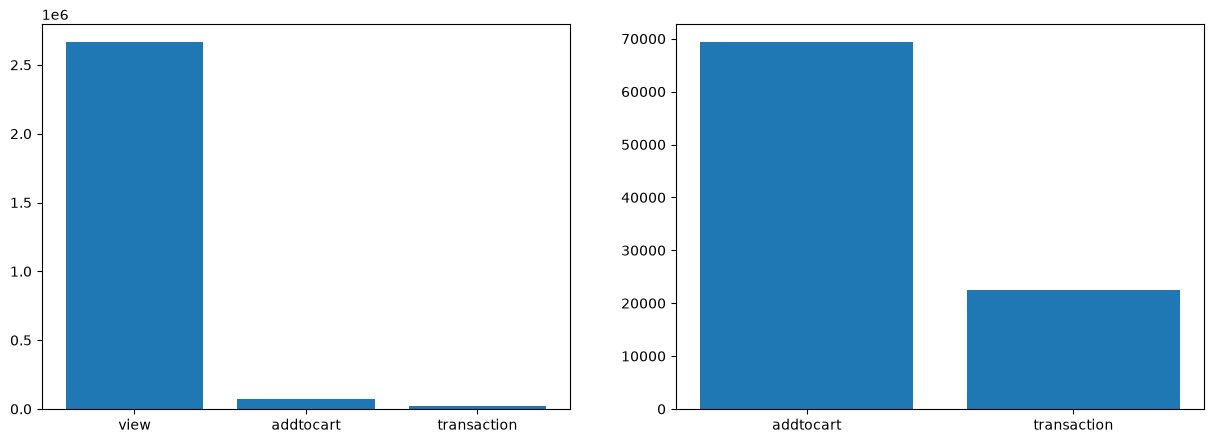

In [10]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.bar(events_count.index, events_count.values)

plt.subplot(1,2,2)
plt.bar(events_count.index[1:], events_count.values[1:])

plt.show()

In [11]:
events_df['transactionid'].dropna().shape[0]

22457

In [12]:
events_df['transactionid'].dropna().unique().shape[0]

17672

In [13]:
events_df['itemid'].size

2756101

In [14]:
events_df['itemid'].unique().size

235061

In [15]:
grupped = events_df.groupby('event')['itemid'].apply(np.array)
grupped

event
addtocart      [5206, 10572, 255275, 356475, 312728, 63312, 1...
transaction    [356475, 15335, 81345, 150318, 310791, 54058, ...
view           [355908, 248676, 318965, 253185, 367447, 22556...
Name: itemid, dtype: object

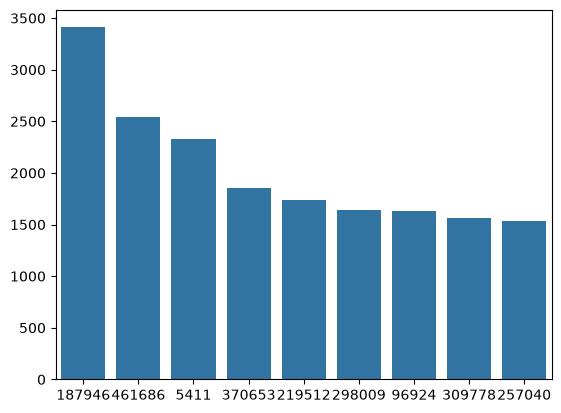

In [16]:
import operator
views = grupped['view']
count_view = {}
views = np.array(views[:])
unique, counts = np.unique(views, return_counts=True)
count_view = dict(zip(unique, counts))
sort_count_view = sorted(count_view.items(), key=operator.itemgetter(1), reverse=True)
x = [i[0] for i in sort_count_view[:9]]
y = [i[1] for i in sort_count_view[:9]]

sns.barplot(x=x, y=y, order=x)
plt.show()


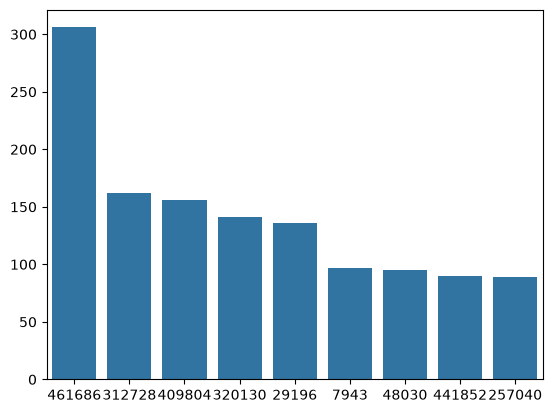

In [17]:
addtocart = grupped['addtocart']
count_addtocart = {}
addtocart = np.array(addtocart[:])
unique, counts = np.unique(addtocart, return_counts=True)
count_addtocart = dict(zip(unique, counts))
sort_count_addtocart = sorted(count_addtocart.items(), key=operator.itemgetter(1), reverse=True)
x = [i[0] for i in sort_count_addtocart[:9]]
y = [i[1] for i in sort_count_addtocart[:9]]

sns.barplot(x=x, y=y, order=x)
plt.show()

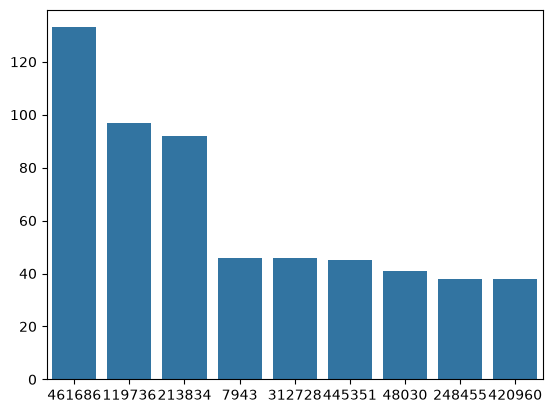

In [18]:
transaction = grupped['transaction']
count_transactiont = {}
transaction = np.array(transaction[:])
unique, counts = np.unique(transaction, return_counts=True)
count_transaction = dict(zip(unique, counts))
sort_count_transaction = sorted(count_transaction.items(), key=operator.itemgetter(1), reverse=True)
x = [i[0] for i in sort_count_transaction[:9]]
y = [i[1] for i in sort_count_transaction[:9]]

sns.barplot(x=x, y=y, order=x)
plt.show()

In [19]:
customer_purchased = events_df[events_df.transactionid.notnull()].visitorid.unique()

purchased_items = []
for customer in customer_purchased:
    purchased_items.append(list(events_df.loc[(events_df.visitorid == customer) & (events_df.transactionid.notnull())].itemid.values))

In [20]:
purchased_items[:3]

[[np.int64(356475)],
 [np.int64(15335),
  np.int64(380775),
  np.int64(237753),
  np.int64(317178),
  np.int64(12836),
  np.int64(400969),
  np.int64(105792),
  np.int64(25353),
  np.int64(200793),
  np.int64(80582),
  np.int64(302422)],
 [np.int64(81345)]]

In [21]:
def reccomend_items(item_id, purchased_items):
    recommtndation_list = []
    for x in purchased_items:
        if item_id in x:
            recommtndation_list += x

    recommtndation_list = list(set(recommtndation_list)-set([item_id]))
    return recommtndation_list

In [28]:
reccomend_items(25353, purchased_items)

[np.int64(105792),
 np.int64(200793),
 np.int64(12836),
 np.int64(80582),
 np.int64(380775),
 np.int64(15335),
 np.int64(400969),
 np.int64(302422),
 np.int64(237753),
 np.int64(317178)]